# 03 Results Summary

This notebook summarizes baseline comparisons, ranking metrics, and candidate lists.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path('outputs')
metrics_df = pd.read_csv(output_dir / 'baseline_metrics.csv')
rank_metrics_df = pd.read_csv(output_dir / 'ranking_metrics_per_cell_line.csv')
agg_metrics_df = pd.read_csv(output_dir / 'aggregate_metrics.csv')

metrics_df

,feature_set,structure_method,model,roc_auc,pr_auc
0,structure_only,smiles_ngrams,lightgbm_classifier,0.680387,0.766614
1,structure_pathway,smiles_ngrams,lightgbm_classifier,0.673973,0.758869
2,structure_expanded,smiles_ngrams,lightgbm_classifier,0.703437,0.787944


In [3]:
rank_metrics_df.head()

,cell_line,k,precision_at_k,recall_at_k,ndcg_at_k,map_at_k,feature_set,model
0,A172,10,1.00,0.050505,1.000000,1.000000,structure_only,lightgbm_classifier
1,A172,25,0.92,0.116162,0.942775,0.978432,structure_only,lightgbm_classifier
2,A172,50,0.88,0.222222,0.902856,0.929910,structure_only,lightgbm_classifier
3,H4,10,1.00,0.051546,1.000000,1.000000,structure_only,lightgbm_classifier
4,H4,25,0.96,0.123711,0.969914,0.981865,structure_only,lightgbm_classifier


## Baseline Comparison

In [4]:
metrics_df.sort_values('roc_auc', ascending=False)

,feature_set,structure_method,model,roc_auc,pr_auc
2,structure_expanded,smiles_ngrams,lightgbm_classifier,0.703437,0.787944
0,structure_only,smiles_ngrams,lightgbm_classifier,0.680387,0.766614
1,structure_pathway,smiles_ngrams,lightgbm_classifier,0.673973,0.758869


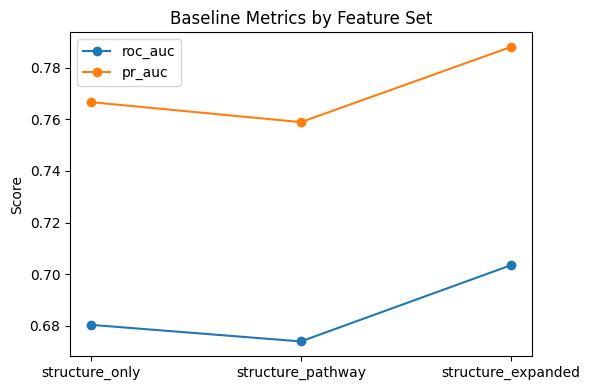

In [5]:
plt.figure(figsize=(6, 4))
for metric in ['roc_auc', 'pr_auc']:
    plt.plot(metrics_df['feature_set'], metrics_df[metric], marker='o', label=metric)
plt.ylabel('Score')
plt.title('Baseline Metrics by Feature Set')
plt.legend()
plt.tight_layout()
plt.show()

## Ranking Metrics Summary

In [6]:
summary = (
    rank_metrics_df.groupby(['feature_set', 'k'])
    .agg({'precision_at_k': 'mean', 'recall_at_k': 'mean', 'ndcg_at_k': 'mean', 'map_at_k': 'mean'})
    .reset_index()
)
summary

,feature_set,k,precision_at_k,recall_at_k,ndcg_at_k,map_at_k
0,structure_expanded,10,1.0000,0.053793,1.000000,1.000000
1,structure_expanded,25,0.8950,0.119248,0.922975,0.968511
2,structure_expanded,50,0.7850,0.210001,0.831523,0.912872
3,structure_only,10,0.8250,0.044361,0.824634,0.857664
4,structure_only,25,0.8150,0.109683,0.819134,0.847840
5,structure_only,50,0.8000,0.214679,0.805800,0.826436
6,structure_pathway,10,0.8750,0.046811,0.912562,0.976644
7,structure_pathway,25,0.8000,0.107054,0.843503,0.910234
8,structure_pathway,50,0.7725,0.206913,0.807569,0.851466


In [7]:
summary.to_csv(output_dir / 'ranking_metrics_summary.csv', index=False)
print('Saved', output_dir / 'ranking_metrics_summary.csv')

Saved outputs/ranking_metrics_summary.csv


## Aggregate Metrics

Aggregate ranking across cell lines using mean score per structure.

In [8]:
agg_metrics_df

,feature_set,model,roc_auc,pr_auc,n_compounds
0,structure_only,lightgbm_classifier,0.661274,0.706794,512
1,structure_only,lambdarank,0.523994,0.620930,512
2,structure_pathway,lightgbm_classifier,0.654371,0.700324,512
3,structure_pathway,lambdarank,0.574308,0.655785,512
4,structure_expanded,lightgbm_classifier,0.686038,0.737082,512
5,structure_expanded,lambdarank,0.535299,0.651597,512


## Next-Step Recommendations

Use the markdown report `results_summary.md` for narrative conclusions and next steps.

In [10]:
baseline_display = (
    metrics_df.loc[:, ["feature_set", "roc_auc", "pr_auc"]]
    .rename(columns={
        "feature_set": "Feature set",
        "roc_auc": "ROC-AUC",
        "pr_auc": "PR-AUC",
    })
    .copy()
)

feature_label_map = {
    "structure_only": "Structure only",
    "structure_pathway": "Structure + CTD pathways",
    "structure_expanded": "Structure + expanded CTD annotations",
}

baseline_display["Feature set"] = baseline_display["Feature set"].map(feature_label_map).fillna(baseline_display["Feature set"])
baseline_display[["ROC-AUC", "PR-AUC"]] = baseline_display[["ROC-AUC", "PR-AUC"]].round(3)
baseline_display.sort_values("ROC-AUC", ascending=False)


,Feature set,ROC-AUC,PR-AUC
2,Structure + expanded CTD annotations,0.703,0.788
0,Structure only,0.680,0.767
1,Structure + CTD pathways,0.674,0.759


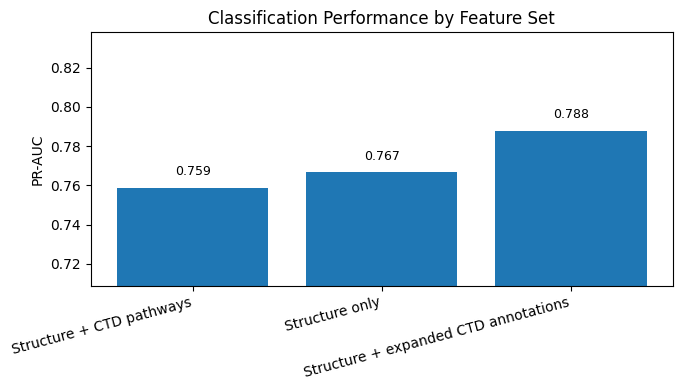

In [11]:
plot_df = metrics_df.copy()
plot_df["feature_label"] = plot_df["feature_set"].map(feature_label_map).fillna(plot_df["feature_set"])
plot_df = plot_df.sort_values("roc_auc", ascending=True)

plt.figure(figsize=(7, 4))
plt.bar(plot_df["feature_label"], plot_df["pr_auc"])
plt.ylabel("PR-AUC")
plt.xlabel("")
plt.title("Classification Performance by Feature Set")
plt.xticks(rotation=15, ha="right")
plt.ylim(max(0, plot_df["pr_auc"].min() - 0.05), min(1.0, plot_df["pr_auc"].max() + 0.05))
for x, y in zip(plot_df["feature_label"], plot_df["pr_auc"]):
    plt.text(x, y + 0.005, f"{y:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


In [12]:
summary = (
    rank_metrics_df.groupby(["feature_set", "model", "k"], as_index=False)
    .agg({
        "precision_at_k": "mean",
        "recall_at_k": "mean",
        "ndcg_at_k": "mean",
        "map_at_k": "mean",
    })
)

summary.to_csv(output_dir / "ranking_metrics_summary.csv", index=False)
print("Saved", output_dir / "ranking_metrics_summary.csv")
summary.head()


Saved outputs/ranking_metrics_summary.csv


,feature_set,model,k,precision_at_k,recall_at_k,ndcg_at_k,map_at_k
0,structure_expanded,lambdarank,10,1.000,0.053793,1.000000,1.000000
1,structure_expanded,lambdarank,25,0.850,0.112570,0.889163,0.954443
2,structure_expanded,lambdarank,50,0.685,0.183293,0.752816,0.876135
3,structure_expanded,lightgbm_classifier,10,1.000,0.053793,1.000000,1.000000
4,structure_expanded,lightgbm_classifier,25,0.940,0.125925,0.956788,0.982578


In [13]:
expanded_summary = (
    summary.loc[summary["feature_set"] == "structure_expanded", ["model", "k", "precision_at_k", "recall_at_k", "ndcg_at_k", "map_at_k"]]
    .copy()
)

model_label_map = {
    "lightgbm_classifier": "Classifier-based ranking",
    "lambdarank": "LambdaRank",
}

expanded_summary["model"] = expanded_summary["model"].map(model_label_map).fillna(expanded_summary["model"])
expanded_summary = expanded_summary.rename(columns={
    "model": "Ranking model",
    "k": "K",
    "precision_at_k": "Precision@K",
    "recall_at_k": "Recall@K",
    "ndcg_at_k": "NDCG@K",
    "map_at_k": "MAP@K",
})
for c in ["Precision@K", "Recall@K", "NDCG@K", "MAP@K"]:
    expanded_summary[c] = expanded_summary[c].round(3)
expanded_summary


,Ranking model,K,Precision@K,Recall@K,NDCG@K,MAP@K
0,LambdaRank,10,1.000,0.054,1.000,1.000
1,LambdaRank,25,0.850,0.113,0.889,0.954
2,LambdaRank,50,0.685,0.183,0.753,0.876
3,Classifier-based ranking,10,1.000,0.054,1.000,1.000
4,Classifier-based ranking,25,0.940,0.126,0.957,0.983
5,Classifier-based ranking,50,0.885,0.237,0.910,0.950


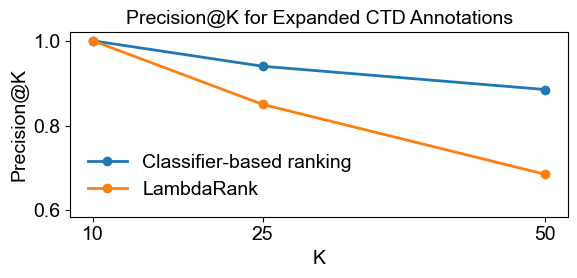

In [18]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Illustrator compatibility
# - SVG: text as paths
# - PDF: TrueType embedding
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "path"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# same font size everywhere
FONT_SIZE = 14
mpl.rcParams["font.size"] = FONT_SIZE
mpl.rcParams["axes.titlesize"] = FONT_SIZE
mpl.rcParams["axes.labelsize"] = FONT_SIZE
mpl.rcParams["xtick.labelsize"] = FONT_SIZE
mpl.rcParams["ytick.labelsize"] = FONT_SIZE
mpl.rcParams["legend.fontsize"] = FONT_SIZE

plot_rank = summary.loc[summary["feature_set"] == "structure_expanded"].copy()
plot_rank["model_label"] = plot_rank["model"].map(model_label_map).fillna(plot_rank["model"])
plot_rank = plot_rank.sort_values(["model_label", "k"])

fig, ax = plt.subplots(figsize=(6, 3))

for model_name, sub_df in plot_rank.groupby("model_label"):
    ax.plot(
        sub_df["k"],
        sub_df["precision_at_k"],
        marker="o",
        linewidth=2,
        label=model_name,
    )

ax.set_xlabel("K")
ax.set_ylabel("Precision@K")
ax.set_title("Precision@K for Expanded CTD Annotations")
ax.set_xticks(sorted(plot_rank["k"].unique()))
ax.set_ylim(max(0, plot_rank["precision_at_k"].min() - 0.1), 1.02)
ax.legend(frameon=False)

plt.tight_layout()

# save for Illustrator
fig.savefig("precision_at_k_expanded_annotations.svg", bbox_inches="tight")
fig.savefig("precision_at_k_expanded_annotations.pdf", bbox_inches="tight")

plt.show()

In [15]:
agg_display = agg_metrics_df.copy()
agg_display["feature_set"] = agg_display["feature_set"].map(feature_label_map).fillna(agg_display["feature_set"])
agg_display["model"] = agg_display["model"].map(model_label_map).fillna(agg_display["model"])
agg_display = agg_display.rename(columns={
    "feature_set": "Feature set",
    "model": "Model",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "n_compounds": "N compounds",
})
agg_display[["ROC-AUC", "PR-AUC"]] = agg_display[["ROC-AUC", "PR-AUC"]].round(3)
agg_display.sort_values(["Feature set", "Model"])


,Feature set,Model,ROC-AUC,PR-AUC,N compounds
2,Structure + CTD pathways,Classifier-based ranking,0.654,0.700,512
3,Structure + CTD pathways,LambdaRank,0.574,0.656,512
4,Structure + expanded CTD annotations,Classifier-based ranking,0.686,0.737,512
5,Structure + expanded CTD annotations,LambdaRank,0.535,0.652,512
0,Structure only,Classifier-based ranking,0.661,0.707,512
1,Structure only,LambdaRank,0.524,0.621,512
